# Part 5 — Model Comparison, DBSCAN & Final Summary

## 8. Model Comparison — KMeans vs Agglomerative vs DBSCAN

            Model  Silhouette  Davies-Bouldin  Calinski-H
       KMeans K=5      0.5547          0.5722       248.6
Agglomerative K=5      0.5538          0.5779       244.4
       KMeans K=6      0.5399          0.6546       243.1
       KMeans K=4      0.4939          0.7096       174.6
Agglomerative K=4      0.4926          0.6707       169.7


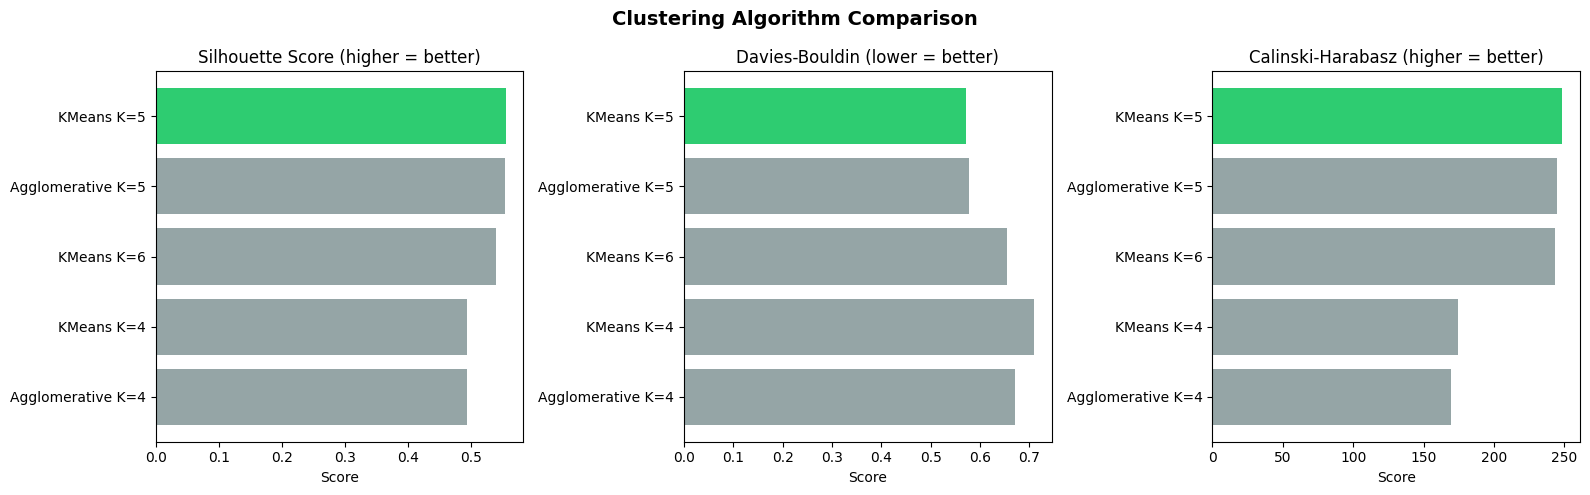

In [13]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN

results = []
for name, model in [
    ('KMeans K=5',        KMeans(n_clusters=5, random_state=42, n_init=10)),
    ('KMeans K=4',        KMeans(n_clusters=4, random_state=42, n_init=10)),
    ('KMeans K=6',        KMeans(n_clusters=6, random_state=42, n_init=10)),
    ('Agglomerative K=5', AgglomerativeClustering(n_clusters=5)),
    ('Agglomerative K=4', AgglomerativeClustering(n_clusters=4)),
]:
    labels = model.fit_predict(X)
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    results.append({'Model': name, 'Silhouette': round(sil,4),
                    'Davies-Bouldin': round(db,4), 'Calinski-H': round(ch,1)})

results_df = pd.DataFrame(results).sort_values('Silhouette', ascending=False)
print(results_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_bar = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(results_df))]

axes[0].barh(results_df['Model'], results_df['Silhouette'], color=colors_bar)
axes[0].set_title('Silhouette Score (higher = better)')
axes[0].set_xlabel('Score')
axes[0].invert_yaxis()

axes[1].barh(results_df['Model'], results_df['Davies-Bouldin'],
             color=['#2ecc71' if v == results_df['Davies-Bouldin'].min() else '#95a5a6'
                    for v in results_df['Davies-Bouldin']])
axes[1].set_title('Davies-Bouldin (lower = better)')
axes[1].set_xlabel('Score')
axes[1].invert_yaxis()

axes[2].barh(results_df['Model'], results_df['Calinski-H'],
             color=['#2ecc71' if v == results_df['Calinski-H'].max() else '#95a5a6'
                    for v in results_df['Calinski-H']])
axes[2].set_title('Calinski-Harabasz (higher = better)')
axes[2].set_xlabel('Score')
axes[2].invert_yaxis()

plt.suptitle('Clustering Algorithm Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Bonus — DBSCAN Comparison

DBSCAN — clusters: 2, noise points: 8


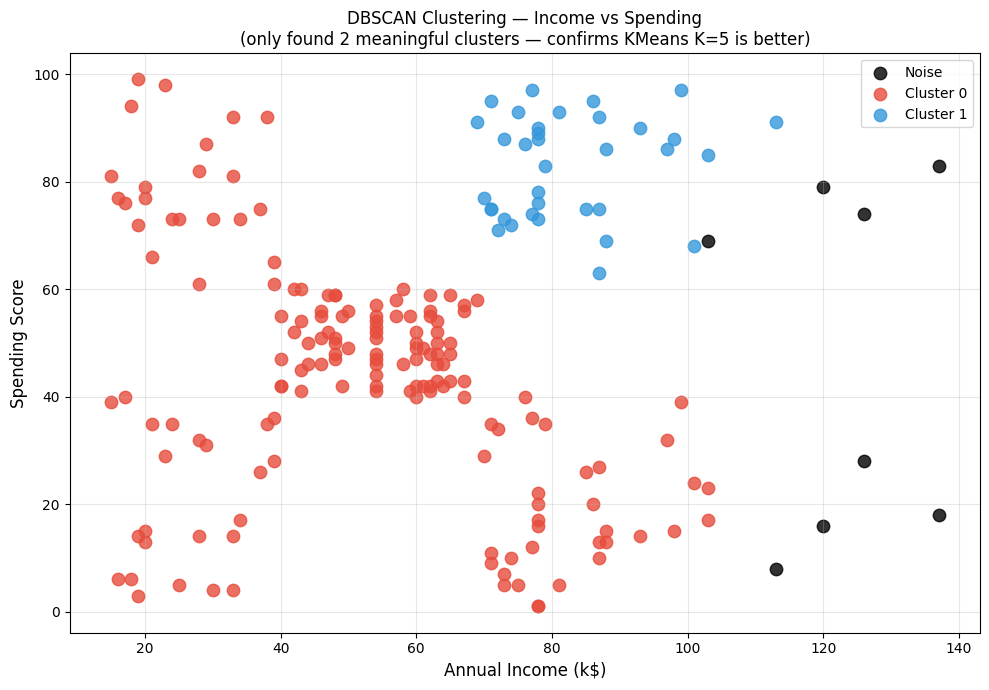

In [15]:
db_labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(X)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
print(f"DBSCAN — clusters: {n_clusters}, noise points: {n_noise}")

plt.figure(figsize=(10, 7))
unique_labels = sorted(set(db_labels))
for lbl in unique_labels:
    mask   = db_labels == lbl
    color  = 'black' if lbl == -1 else COLORS[lbl % len(COLORS)]
    label  = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    plt.scatter(df[mask]['Income'], df[mask]['Spending'],
                c=color, label=label, s=80, alpha=0.8)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title('DBSCAN Clustering — Income vs Spending\n(only found 2 meaningful clusters — confirms KMeans K=5 is better)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Final Summary

In [16]:
print("=" * 60)
print("     CUSTOMER SEGMENTATION — FINAL SUMMARY")
print("=" * 60)

summary = (
    "\nBEST MODEL: KMeans K=5 on Income vs Spending Score\n"
    "  Silhouette       : 0.5547\n"
    "  Davies-Bouldin   : 0.5722\n"
    "  Calinski-Harabasz: 248.6\n"
)
print(summary)

print("CLUSTER PROFILES:")
print("-" * 60)
print(f"  {'Cluster':<10} {'Segment':<32} {'Avg Age':>7} {'Avg Inc':>8} {'Avg Spe':>8} {'Count':>6}")
print("-" * 60)

for c in range(BEST_K):
    row = profile.iloc[c]
    print(f"  {c:<10} {SEGMENT_NAMES[c]:<32} {row['Age']:>7.1f} {row['Income']:>8.1f} {row['Spending']:>8.1f} {int(row['Count']):>6}")

print()
print("KEY FINDINGS:")
print("  1. Income and Spending Score are the strongest clustering signals")
print("  2. Age has weak correlation with spending (-0.33) and income (-0.01)")
print("  3. Gender distribution is nearly equal across all clusters")
print("  4. DBSCAN found only 2 clusters -- KMeans K=5 gives richer segmentation")
print("  5. High income does NOT guarantee high spending (clusters 3 & 4)")
print("  6. Young low-income customers can still be high spenders (cluster 2)")
print("=" * 60)

     CUSTOMER SEGMENTATION — FINAL SUMMARY

BEST MODEL: KMeans K=5 on Income vs Spending Score
  Silhouette       : 0.5547
  Davies-Bouldin   : 0.5722
  Calinski-Harabasz: 248.6

CLUSTER PROFILES:
------------------------------------------------------------
  Cluster    Segment                          Avg Age  Avg Inc  Avg Spe  Count
------------------------------------------------------------
  0          Average Customers                   42.7     55.3     49.5     81
  1          High Income High Spenders           32.7     86.5     82.1     39
  2          Low Income High Spenders            25.3     25.7     79.4     22
  3          High Income Low Spenders            41.1     88.2     17.1     35
  4          Low Income Low Spenders             45.2     26.3     20.9     23

KEY FINDINGS:
  1. Income and Spending Score are the strongest clustering signals
  2. Age has weak correlation with spending (-0.33) and income (-0.01)
  3. Gender distribution is nearly equal across all c